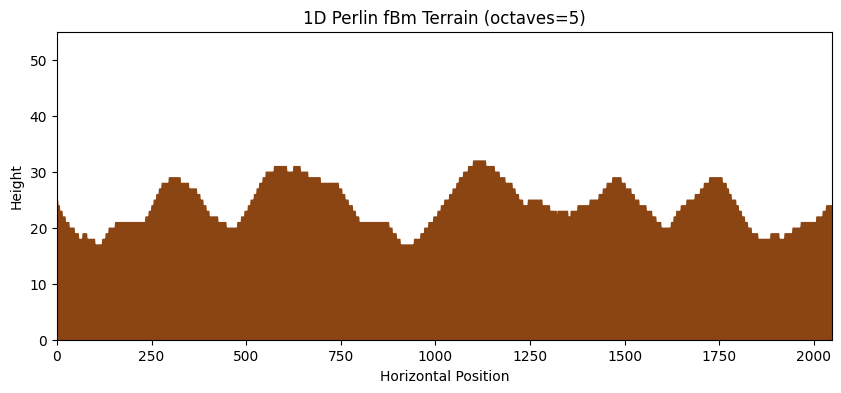

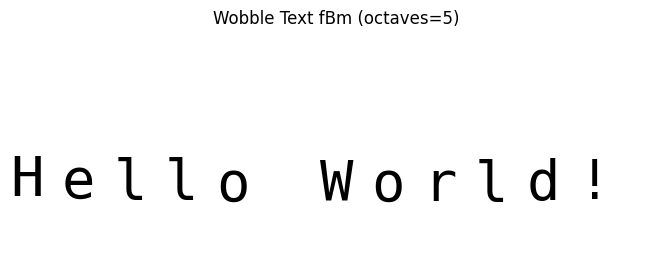

In [ ]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np

# ─── Permutation table (0–255 shuffled, duplicated) ─────────────────────────────
_perm = list(range(256))
random.seed(0)
random.shuffle(_perm)
_perm += _perm

def fade(t):
    return t * t * t * (t * (t * 6 - 15) + 10)

def lerp(a, b, t):
    return a + t * (b - a)

def grad(hash_val, x):

def perlin1d(x):
    x0 = math.floor(x)
    x1 = x0 + 1
    dx0 = x - x0
    dx1 = dx0 - 1.0
    h0 = _perm[x0 & 255]
    h1 = _perm[x1 & 255]
    dot0 = grad(h0, dx0)
    dot1 = grad(h1, dx1)
    u = fade(dx0)
    return lerp(dot0, dot1, u)

def fbm1d(x, octaves=4, persistence=0.5, lacunarity=2.0):
    """
    Fractal Brownian Motion in 1D:
      sum_{i=0..octaves-1} (perlin1d(x * lacunarity^i) * persistence^i)
    """
    total = 0.0
    amplitude = 1.0
    frequency = 1.0
    max_amp = 0.0
    for _ in range(octaves):
        total += perlin1d(x * frequency) * amplitude
        max_amp += amplitude
        amplitude *= persistence
        frequency *= lacunarity
    return total / max_amp  # normalize to [-1,1]

# ─── Example 1: Side‐Scroller Terrain with Octaves ────────────────────────────────
def generate_terrain_fbm(width, scale, amplitude, base_height,
                         octaves=4, persistence=0.5, lacunarity=2.0):
    heights = np.zeros(width, dtype=int)
    for i in range(width):
        n = fbm1d(i / scale, octaves, persistence, lacunarity)
        mapped = (n + 1) / 2 * amplitude
        heights[i] = int(base_height + mapped)
    return heights

# Plotting terrain
width = 2048
scale = 256
amplitude = 40
base_height = 5
octaves = 5
persistence = 0.4
lacunarity = 2.0

terrain_heights = generate_terrain_fbm(
    width, scale, amplitude, base_height,
    octaves=octaves,
    persistence=persistence,
    lacunarity=lacunarity
)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(width)
ax.fill_between(x, terrain_heights, color='saddlebrown')
ax.set_ylim(0, base_height + amplitude + 10)
ax.set_xlim(0, width)
ax.set_title(f"1D Perlin fBm Terrain (octaves={octaves})")
ax.set_xlabel("Horizontal Position")
ax.set_ylabel("Height")

plt.savefig("./figs/1dmaps.pdf",
            dpi=300,               # resolution in dots per inch
            bbox_inches="tight",   # trim excess whitespace
            transparent=False)     # set True for a transparent background


plt.show()

# ─── Example 2: Wobble Text with Octaves ─────────────────────────────────────────
def wobble_text_fbm(text, font_size=30, amplitude=3, scale=30.0,
                    octaves=4, persistence=0.5, lacunarity=2.0):
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.set_xlim(0, len(text))
    ax.set_ylim(-amplitude*2, font_size + amplitude*2)
    ax.axis('off')
    for i, char in enumerate(text):
        n = fbm1d(i / scale, octaves, persistence, lacunarity)
        y_offset = amplitude * n
        ax.text(i, y_offset + font_size * 0.3, char,
                fontsize=font_size, ha='center', va='center',
                family='monospace')
    ax.set_title(f"Wobble Text fBm (octaves={octaves})")
    plt.show()

# Plotting wobble text
wobble_text_fbm(
    "Hello World!",
    font_size=40,
    amplitude=4,
    scale=20.0,
    octaves=5,
    persistence=0.5,
    lacunarity=2.0
)


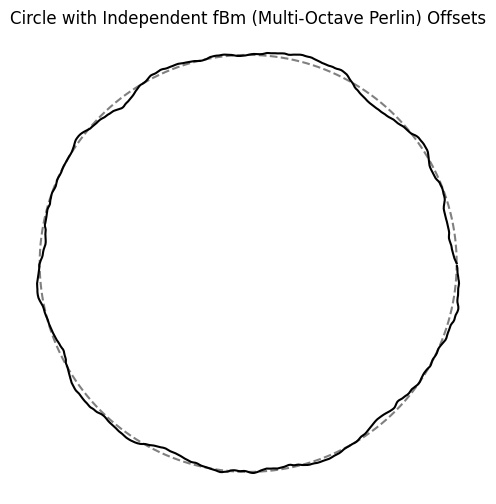

In [3]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

# ─── 1D Perlin‐noise implementation ──────────────────────────────────────────────
_perm = list(range(256))
random.seed(0)
random.shuffle(_perm)
_perm += _perm

def fade(t):
    return t * t * t * (t * (t * 6 - 15) + 10)

def lerp(a, b, t):
    return a + t * (b - a)

def grad(hash_val, x):
    return (1 if (hash_val & 1) == 0 else -1) * x

def perlin1d(x):
    x0 = math.floor(x)
    x1 = x0 + 1
    dx0 = x - x0
    dx1 = dx0 - 1.0
    h0 = _perm[x0 & 255]
    h1 = _perm[x1 & 255]
    dot0 = grad(h0, dx0)
    dot1 = grad(h1, dx1)
    u = fade(dx0)
    return lerp(dot0, dot1, u)

def fbm1d(x, octaves=4, persistence=0.5, lacunarity=2.0):
    """
    Fractal Brownian Motion in 1D:
      sum_{i=0..octaves-1} (perlin1d(x * frequency) * amplitude)
    normalized by the total amplitude.
    """
    total = 0.0
    amplitude = 1.0
    frequency = 1.0
    max_amp = 0.0
    for _ in range(octaves):
        total += perlin1d(x * frequency) * amplitude
        max_amp += amplitude
        amplitude *= persistence
        frequency *= lacunarity
    return total / max_amp  # roughly in [-1, 1]

# ─── Generate circle + independent X/Y noise offsets with octaves ───────────────
num_points = 600
radius     = 1.0

# Jitter amplitude for X and Y
amplitude_x = 0.1
amplitude_y = 0.1

# “Scale” for noise input (larger → gentler curves)
scale_x = 50.0
scale_y = 50.0

# Phase shift for Y‐noise
phase_shift = 37.0

# fBm parameters
octaves     = 5
persistence = 0.5
lacunarity  = 2.0

angles = np.linspace(0, 2 * math.pi, num_points, endpoint=False)
x_base = radius * np.cos(angles)
y_base = radius * np.sin(angles)

# Sample two independent fBm noise curves:
offsets_x = np.array([
    amplitude_x * fbm1d(i / scale_x, octaves, persistence, lacunarity)
    for i in range(num_points)
])
offsets_y = np.array([
    amplitude_y * fbm1d((i / scale_y) + phase_shift, octaves, persistence, lacunarity)
    for i in range(num_points)
])

x_noisy = x_base + offsets_x
y_noisy = y_base + offsets_y

# ─── Plot ───────────────────────────────────────────────────────────────────────
plt.figure(figsize=(6, 6))
# Perfect circle in dashed gray
plt.plot(x_base, y_base, linestyle='--', color='gray', label='Perfect Circle')
# Noisy circle in solid black
plt.plot(x_noisy, y_noisy, color='black', linewidth=1.5, label='Hand‐Drawn Circle (fbm)')

plt.gca().set_aspect('equal', 'box')
plt.axis('off')
plt.title("Circle with Independent fBm (Multi‐Octave Perlin) Offsets")

plt.savefig("./figs/circle_fbm.pdf",
            dpi=300,               # resolution in dots per inch
            bbox_inches="tight",   # trim excess whitespace
            transparent=False)     # set True for a transparent background


plt.show()


In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import imageio

# ─── 1D Perlin‐noise implementation ──────────────────────────────────────────────
_perm = list(range(256))
random.seed(0)
random.shuffle(_perm)
_perm += _perm

def fade(t):
    return t * t * t * (t * (t * 6 - 15) + 10)

def lerp(a, b, t):
    return a + t * (b - a)

def grad(hash_val, x):
    return (1 if (hash_val & 1) == 0 else -1) * x

def perlin1d(x):
    x0 = math.floor(x)
    x1 = x0 + 1
    dx0 = x - x0
    dx1 = dx0 - 1.0
    h0 = _perm[x0 & 255]
    h1 = _perm[x1 & 255]
    dot0 = grad(h0, dx0)
    dot1 = grad(h1, dx1)
    u = fade(dx0)
    return lerp(dot0, dot1, u)

def fbm1d(x, octaves=4, persistence=0.5, lacunarity=2.0):
    """
    Fractal Brownian Motion in 1D:
      sum_{i=0..octaves-1} (perlin1d(x * frequency) * amplitude)
    normalized by the total amplitude.
    """
    total = 0.0
    amplitude = 1.0
    frequency = 1.0
    max_amp = 0.0
    for _ in range(octaves):
        total += perlin1d(x * frequency) * amplitude
        max_amp += amplitude
        amplitude *= persistence
        frequency *= lacunarity
    return total / max_amp  # roughly in [-1, 1]

# ─── Generate circle + independent X/Y noise offsets with octaves ───────────────
num_points = 600
radius     = 1.0

# Jitter amplitude for X and Y
amplitude_x = 0.08
amplitude_y = 0.08

# “Scale” for noise input (larger → gentler curves)
scale_x = 50.0
scale_y = 50.0

# Phase shift for Y‐noise
phase_shift = 37.0

# fBm parameters
octaves     = 4
persistence = 0.5
lacunarity  = 2.0

angles = np.linspace(0, 2 * math.pi, num_points, endpoint=False)
x_base = radius * np.cos(angles)
y_base = radius * np.sin(angles)

# Sample two independent fBm noise curves:
offsets_x = np.array([
    amplitude_x * fbm1d(i / scale_x, octaves, persistence, lacunarity)
    for i in range(num_points)
])
offsets_y = np.array([
    amplitude_y * fbm1d((i / scale_y) + phase_shift, octaves, persistence, lacunarity)
    for i in range(num_points)
])

x_noisy = x_base + offsets_x
y_noisy = y_base + offsets_y

# ─── Animate drawing the noisy circle ────────────────────────────────────────────
num_frames = 100
step = num_points // num_frames

frames = []
for frame_idx in range(1, num_frames + 1):
    end = frame_idx * step
    if frame_idx == num_frames:
        end = num_points
    
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(x_noisy[:end], y_noisy[:end], color='black', linewidth=1.5)
    ax.set_aspect('equal', 'box')
    ax.axis('off')
    ax.set_xlim(-radius - amplitude_x - 0.1, radius + amplitude_x + 0.1)
    ax.set_ylim(-radius - amplitude_y - 0.1, radius + amplitude_y + 0.1)

    fig.canvas.draw()
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    frames.append(image)
    plt.close(fig)

# Save as GIF
gif_path = "./gifs/circle_draw.gif"
imageio.mimsave(gif_path, frames, fps=15)

gif_path


ModuleNotFoundError: No module named 'imageio'